# coding attention machenism 

In [1]:
import torch

In [2]:
import torch
inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your    (x^1)
   [0.55, 0.87, 0.66], # journey (x^2)
   [0.57, 0.85, 0.64], # starts  (x^3)
   [0.22, 0.58, 0.33], # with    (x^4)
   [0.77, 0.25, 0.10], # one     (x^5)
   [0.05, 0.80, 0.55]] # step    (x^6)
)

calculating the dot product with respect to `(x^2)` for all 

the first intermediate step, computing the
attention scores `W` between the query x(2) and all other input elements as a dot product

In [3]:
query = inputs[1]
attn_scores_2 = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
    attn_scores_2[i] += torch.dot(x_i,query)
print(attn_scores_2) 

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


next we will normalize the `W` attention score that sum to 1

lets use `softmax` function to normalize the value of attention score `W`

In [4]:
def softmax(x):
    return torch.exp(x) / torch.exp(x).sum(dim = 0)

attn_weights_2 = softmax(attn_scores_2)
print("attention_sore:",attn_weights_2)
print("sum:",attn_weights_2.sum())

attention_sore: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
sum: tensor(1.)


In [5]:
query = inputs[1]
context_vec_2 = torch.zeros(query.shape)
for i,x_i in enumerate(inputs):
 context_vec_2 += attn_weights_2[i]*x_i
print(context_vec_2)

tensor([0.4419, 0.6515, 0.5683])


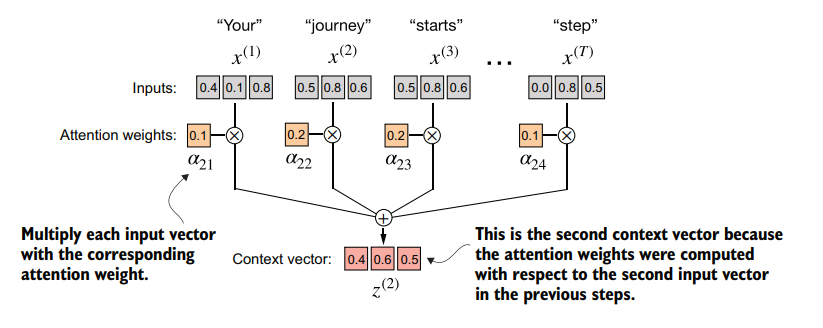

calculating the context vector z
(2) by multiplying the
embedded input tokens, x(i), with the corresponding attention weights and then summing the resulting vectors. Thus, context vector z
(2) is the weighted sum of all input vectors, obtained by multiplying each input vector by its corresponding attention weight:

## Computing attention weights for all input tokens

now lets compute an attention weights for all vectors 

In [8]:
attn_scores = torch.empty(6,6)
for i, x_i in enumerate(inputs):
    for j, x_j in enumerate(inputs):
        attn_scores[i,j] = torch.dot(x_i,x_j)

print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


lets apply normalization in it `softmax`

In [10]:
attn_weights = torch.softmax(attn_scores,dim= -1)
print(attn_weights)

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


In [15]:
all_context_vector = attn_weights @ inputs
print(all_context_vector)



tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])


implementing attention mechanism using `Q K V`

In [17]:
x_2 = inputs[1]  # 2 query of inputs 
in_d = inputs.shape[1]  # dimension of 2 query that is 3
out_d = 2

### Next, we initialize the three weight matrices Wq, Wk, and Wv 

In [20]:

torch.manual_seed(20)
W_Query = torch.nn.Parameter(torch.rand(in_d,out_d), requires_grad = False)
W_Key   = torch.nn.Parameter(torch.rand(in_d,out_d), requires_grad = False)
W_Value = torch.nn.Parameter(torch.rand(in_d,out_d), requires_grad = False)

Next, we compute the query, key, and value vectors:

In [21]:
query_2 = x_2  @ W_Query
key_2  = x_2 @ W_Key
value_2 = x_2 @ W_Value

print("=" * 50)
print(query_2)
print("=" * 50)
print(key_2)
print("=" * 50)
print(value_2)

tensor([1.1706, 0.9012])
tensor([0.6926, 1.0739])
tensor([1.4485, 0.9020])


In [22]:
keys = inputs @ W_Key 
values = inputs @ W_Value
print("keys.shape:", keys.shape)
print("values.shape:", values.shape)

keys.shape: torch.Size([6, 2])
values.shape: torch.Size([6, 2])
